In [ ]:
!pip install wandb

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import wandb
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

wandb.login()

Device: cpu


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:


Loading G1_NURBS...
Shape: torch.Size([990, 3, 128, 128]) torch.Size([990, 3, 128, 128])


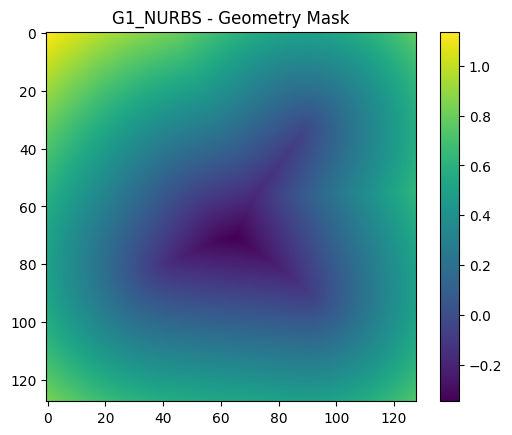

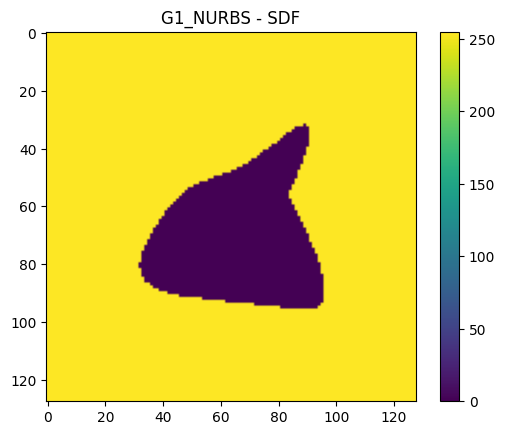

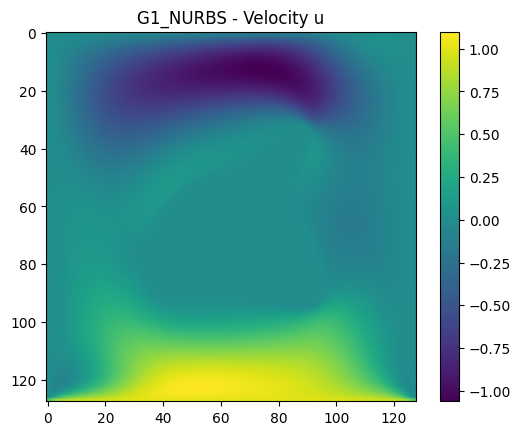

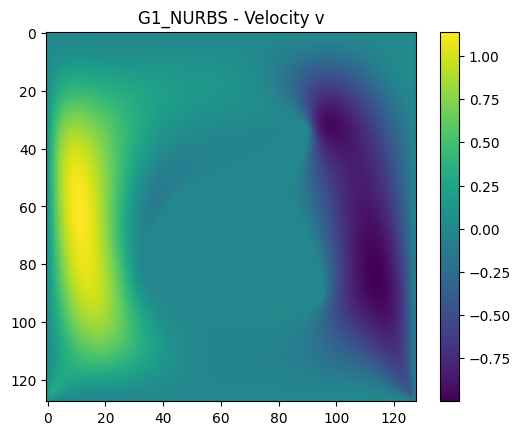

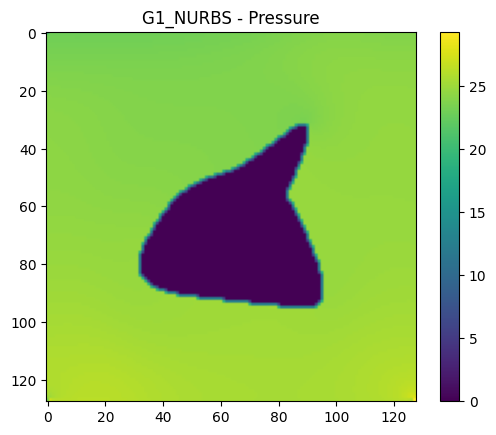


Loading G2_Harmonics...
Shape: torch.Size([1000, 3, 128, 128]) torch.Size([1000, 3, 128, 128])


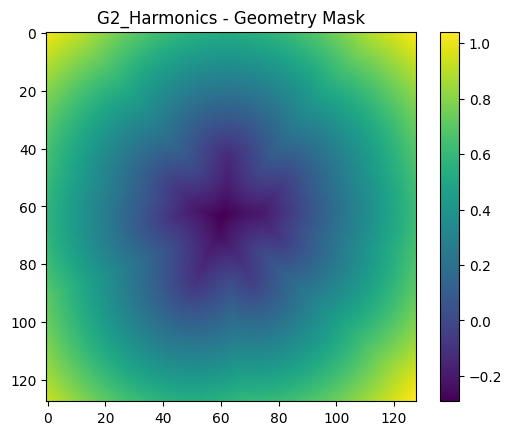

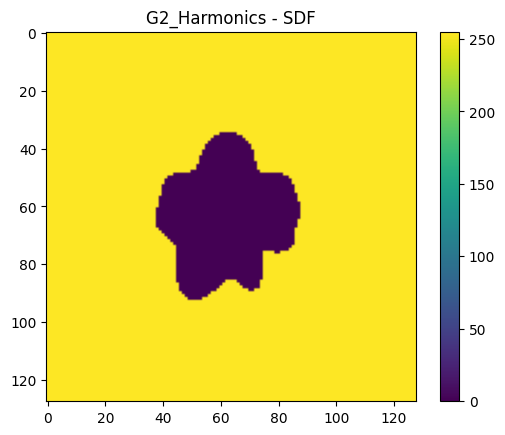

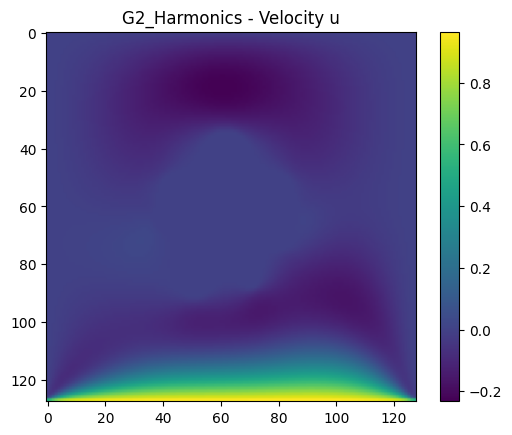

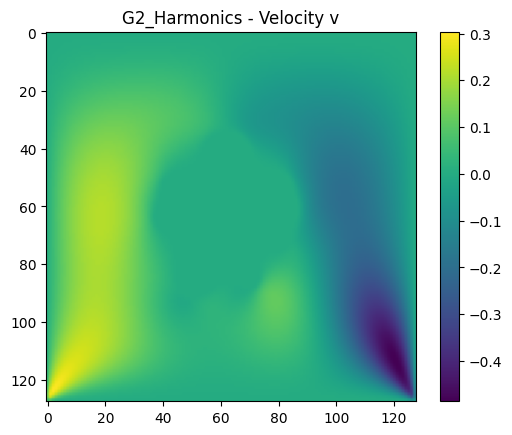

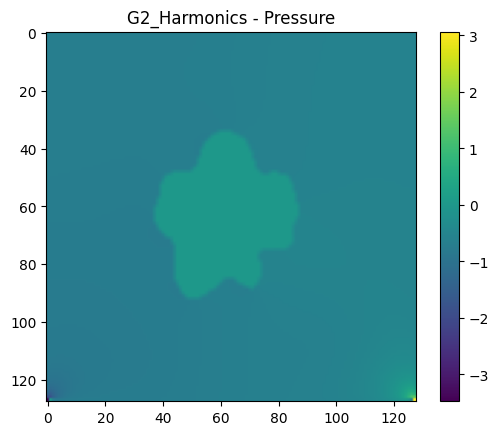


Loading G3_Skeleton...
Shape: torch.Size([1000, 3, 128, 128]) torch.Size([1000, 3, 128, 128])


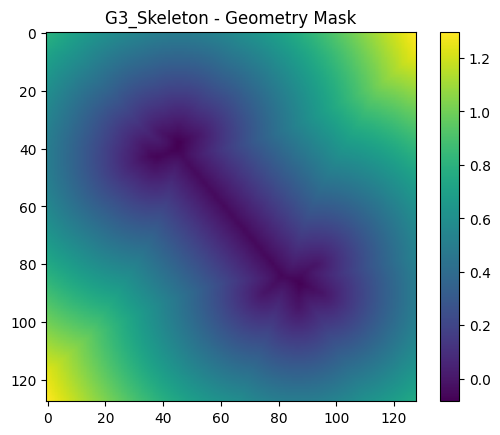

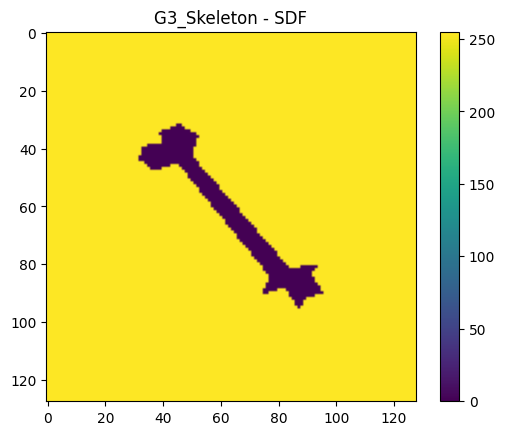

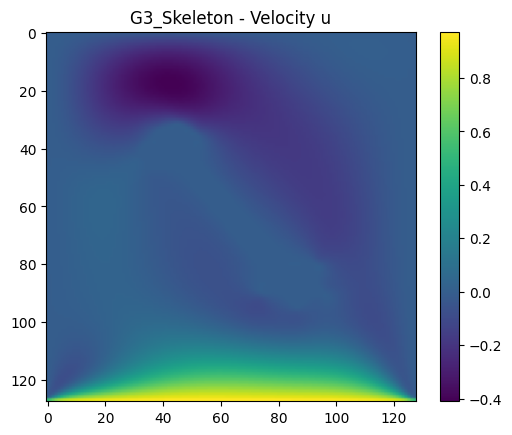

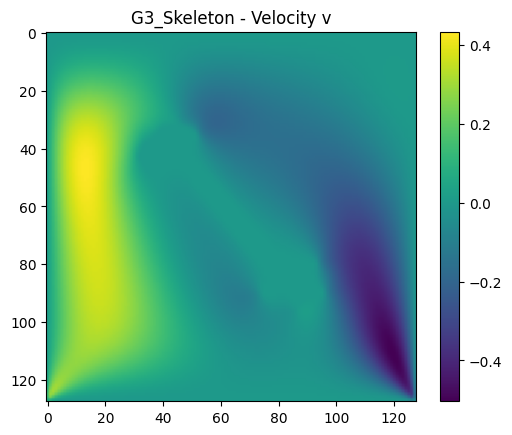

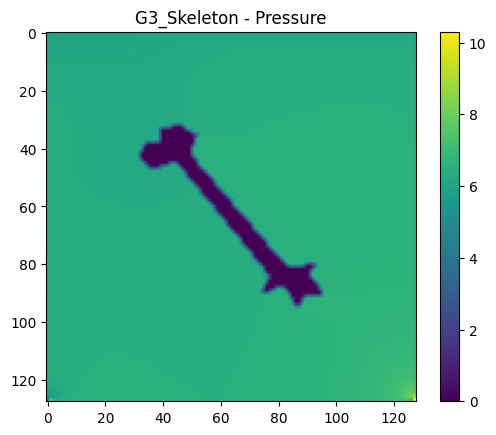

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Update file names EXACTLY as they appear in your folder
paths = {
    "G1_NURBS": (
        "/content/drive/MyDrive/LDC Dataset/nurbs_lid_driven_cavity_X.npz",
        "/content/drive/MyDrive/LDC Dataset/nurbs_lid_driven_cavity_Y.npz"
    ),
    "G2_Harmonics": (
        "/content/drive/MyDrive/LDC Dataset/harmonics_lid_driven_cavity_X.npz",
        "/content/drive/MyDrive/LDC Dataset/harmonics_lid_driven_cavity_Y.npz"
    ),
    "G3_Skeleton": (
        "/content/drive/MyDrive/LDC Dataset/skelneton_lid_driven_cavity_X.npz",
        "/content/drive/MyDrive/LDC Dataset/skelneton_lid_driven_cavity_Y.npz"
    )
}

def visualize_sample(X, Y, name, idx=0):

    geometry_mask = X[idx, 1].numpy()
    sdf = X[idx, 2].numpy()
    u = Y[idx, 0].numpy()
    v = Y[idx, 1].numpy()
    p = Y[idx, 2].numpy()

    plt.figure()
    plt.imshow(geometry_mask)
    plt.title(f"{name} - Geometry Mask")
    plt.colorbar()
    plt.show()

    plt.figure()
    plt.imshow(sdf)
    plt.title(f"{name} - SDF")
    plt.colorbar()
    plt.show()

    plt.figure()
    plt.imshow(u)
    plt.title(f"{name} - Velocity u")
    plt.colorbar()
    plt.show()

    plt.figure()
    plt.imshow(v)
    plt.title(f"{name} - Velocity v")
    plt.colorbar()
    plt.show()

    plt.figure()
    plt.imshow(p)
    plt.title(f"{name} - Pressure")
    plt.colorbar()
    plt.show()


for name, (x_path, y_path) in paths.items():
    print(f"\nLoading {name}...")

    X_data = np.load(x_path)["data"]
    Y_data = np.load(y_path)["data"]

    Y_data = Y_data[:, 0:3, :, :]  # keep u,v,p

    X = torch.tensor(X_data, dtype=torch.float32)
    Y = torch.tensor(Y_data, dtype=torch.float32)

    print("Shape:", X.shape, Y.shape)

    visualize_sample(X, Y, name, idx=0)

# Model

In [ ]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=256, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, x):
        return self.net(x)

class DeepONet(nn.Module):
    def __init__(self, branch_dim, latent_dim=256):
        super().__init__()
        self.branch = MLP(branch_dim, hidden=256, out_dim=latent_dim)
        self.trunk  = MLP(2, hidden=256, out_dim=latent_dim*3)
        self.latent_dim = latent_dim

    def forward(self, branch_input, coords):
        B = branch_input.shape[0]
        branch_out = self.branch(branch_input)
        trunk_out  = self.trunk(coords)
        trunk_out  = trunk_out.view(-1, 3, self.latent_dim)

        branch_out = branch_out.unsqueeze(1)
        output = torch.einsum("bik,nik->bni", branch_out, trunk_out)
        return output

In [ ]:
def relative_l2(pred, true):
    return torch.norm(pred - true) / torch.norm(true)

# Training

In [ ]:
def train_geometry(X_data, Y_data, geometry_name):

    print(f"\n===== Training on {geometry_name} =====")

    # Downsample to 128x128
    X_data = X_data[:, :, ::4, ::4]
    Y_data = Y_data[:, 0:3, ::4, ::4]

    X = torch.tensor(X_data, dtype=torch.float32)
    Y = torch.tensor(Y_data, dtype=torch.float32)

    X_train, X_val, Y_train, Y_val = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    X_train = X_train.to(device)
    Y_train = Y_train.to(device)
    X_val   = X_val.to(device)
    Y_val   = Y_val.to(device)

    N, C, H, W = X_train.shape

    # Coordinate grid
    x = torch.linspace(0, 1, H)
    y = torch.linspace(0, 1, W)
    grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')
    coords = torch.stack([grid_x, grid_y], dim=-1)
    coords = coords.reshape(-1, 2).to(device)

    train_loader = DataLoader(
        TensorDataset(X_train, Y_train),
        batch_size=4,
        shuffle=True
    )

    model = DeepONet(branch_dim=3*H*W).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    mse = nn.MSELoss()

    epochs = 100
    best_val_l2 = 1e9

    # Initialize W&B per geometry
    wandb.init(
        project="SciML-Geometry-Comparison",
        name=f"DeepONet_{geometry_name}",
        config={
            "epochs": epochs,
            "lr": 5e-4,
            "batch_size": 4,
            "resolution": H,
            "latent_dim": 256,
            "geometry": geometry_name
        }
    )

    for epoch in range(epochs):

        model.train()
        train_loss = 0

        for x_batch, y_batch in train_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            x_batch = x_batch.reshape(x_batch.shape[0], -1)

            pred = model(x_batch, coords)
            pred = pred.view(-1, H, W, 3).permute(0,3,1,2)

            loss = mse(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # Validation
        model.eval()
        with torch.no_grad():
            x_val_flat = X_val.reshape(X_val.shape[0], -1)
            pred_val = model(x_val_flat, coords)
            pred_val = pred_val.view(-1, H, W, 3).permute(0,3,1,2)

            val_loss = mse(pred_val, Y_val)
            val_l2 = relative_l2(pred_val, Y_val)

        if val_l2.item() < best_val_l2:
            best_val_l2 = val_l2.item()

        # Log per epoch
        wandb.log({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss.item(),
            "val_rel_L2": val_l2.item(),
            "best_val_rel_L2": best_val_l2
        })

        if epoch % 10 == 0:
            print(f"{geometry_name} | Epoch {epoch} | Val L2: {val_l2.item():.4f}")

    wandb.finish()

    return {
        "geometry": geometry_name,
        "final_train_loss": train_loss,
        "final_val_loss": val_loss.item(),
        "best_val_rel_L2": best_val_l2
    }

In [ ]:
import pandas as pd
paths = {
    "G1_NURBS": (
        "/content/drive/MyDrive/LDC Dataset/nurbs_lid_driven_cavity_X.npz",
        "/content/drive/MyDrive/LDC Dataset/nurbs_lid_driven_cavity_Y.npz"
    ),
    "G2_Harmonics": (
        "/content/drive/MyDrive/LDC Dataset/harmonics_lid_driven_cavity_X.npz",
        "/content/drive/MyDrive/LDC Dataset/harmonics_lid_driven_cavity_Y.npz"
    ),
    "G3_Skeleton": (
        "/content/drive/MyDrive/LDC Dataset/skelneton_lid_driven_cavity_X.npz",
        "/content/drive/MyDrive/LDC Dataset/skelneton_lid_driven_cavity_Y.npz"
    )
}



results = []

for name, (x_path, y_path) in paths.items():

    X_data = np.load(x_path)["data"]
    Y_data = np.load(y_path)["data"]

    metrics = train_geometry(X_data, Y_data, name)
    results.append(metrics)

df = pd.DataFrame(results)
print("\n===== Comparison Table =====")
print(df)


===== Training on G1_NURBS =====


G1_NURBS | Epoch 0 | Val L2: 10.7491
G1_NURBS | Epoch 10 | Val L2: 1.4873
G1_NURBS | Epoch 20 | Val L2: 1.0629
G1_NURBS | Epoch 30 | Val L2: 0.9997
G1_NURBS | Epoch 40 | Val L2: 0.9997
G1_NURBS | Epoch 50 | Val L2: 0.9995
G1_NURBS | Epoch 60 | Val L2: 0.9994
G1_NURBS | Epoch 70 | Val L2: 0.9993
G1_NURBS | Epoch 80 | Val L2: 0.9991
G1_NURBS | Epoch 90 | Val L2: 1.0042


best_val_rel_L2,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇█████
train_loss,▄▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁
val_loss,█▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_rel_L2,▂█▂▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_rel_L2,0.99889
epoch,99
train_loss,22.64511
val_loss,22.74283
val_rel_L2,0.99929



===== Training on G2_Harmonics =====


G2_Harmonics | Epoch 0 | Val L2: 9.6430
G2_Harmonics | Epoch 10 | Val L2: 2.6227
G2_Harmonics | Epoch 20 | Val L2: 2.2836
G2_Harmonics | Epoch 30 | Val L2: 0.9989
G2_Harmonics | Epoch 40 | Val L2: 0.9982
G2_Harmonics | Epoch 50 | Val L2: 0.9987
G2_Harmonics | Epoch 60 | Val L2: 0.9985
G2_Harmonics | Epoch 70 | Val L2: 0.9989
G2_Harmonics | Epoch 80 | Val L2: 1.6220
G2_Harmonics | Epoch 90 | Val L2: 1.4358


best_val_rel_L2,█▅▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇███
train_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▂▁▁▁▁▁▁
val_loss,▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_rel_L2,▃▁▁▂▂█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▁▁▁▁▁▁
best_val_rel_L2,0.99814
epoch,99
train_loss,23.58474
val_loss,23.07037
val_rel_L2,1.39715



===== Training on G3_Skeleton =====


G3_Skeleton | Epoch 0 | Val L2: 1.1498
G3_Skeleton | Epoch 10 | Val L2: 0.9999
G3_Skeleton | Epoch 20 | Val L2: 0.9998
G3_Skeleton | Epoch 30 | Val L2: 0.9998
G3_Skeleton | Epoch 40 | Val L2: 1.0001
G3_Skeleton | Epoch 50 | Val L2: 1.0000
G3_Skeleton | Epoch 60 | Val L2: 1.0002
G3_Skeleton | Epoch 70 | Val L2: 0.9999
G3_Skeleton | Epoch 80 | Val L2: 0.9998
G3_Skeleton | Epoch 90 | Val L2: 1.0003


best_val_rel_L2,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇███
train_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▅▁▃▁▁▁▁▁
val_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_rel_L2,█▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_rel_L2,0.99948
epoch,99
train_loss,10251.02468
val_loss,7825.15527
val_rel_L2,1.00025



===== Comparison Table =====
       geometry  final_train_loss  final_val_loss  best_val_rel_L2
0      G1_NURBS         22.645111       22.742832         0.998892
1  G2_Harmonics         23.584744       23.070368         0.998141
2   G3_Skeleton      10251.024685     7825.155273         0.999484
